In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize, brentq

# MI Parameters
a1 = 883.58722
a2 = 0.35408
a3 = 0.755684
a4 = 0.826155
b1 = 0.963532

# Pre-Trade TCA Functions (from HW7)
def MI(Size, Volatility, POV, a1=a1, a2=a2, a3=a3, a4=a4, b1=b1):
    """Market Impact (in bps)"""
    Istar = a1 * (Size ** a2) * (Volatility ** a3)
    mi = Istar * (b1 * (POV ** a4) + (1 - b1))
    return mi

def TR(Volatility, TradeTime):
    """Timing Risk (in bps)"""
    tr = Volatility * np.sqrt((1/3) * (1/250) * TradeTime) * 10000
    return tr

def PA(Side, AlphaBp, TradeTime):
    """Price Appreciation (in bps)"""
    pa = Side * 0.5 * AlphaBp * TradeTime
    return pa

def PovToTime(Size, POV):
    """Convert POV rate to Trade Time"""
    return Size * (1 - POV) / POV

def TimeToPOV(Size, TradeTime):
    """Convert Trade Time to POV rate"""
    return Size / (Size + TradeTime)

--Q1 Results ---
Optimal POV: 13.63%
MI: 30.47
TR: 72.68
Trade Time: 0.6339


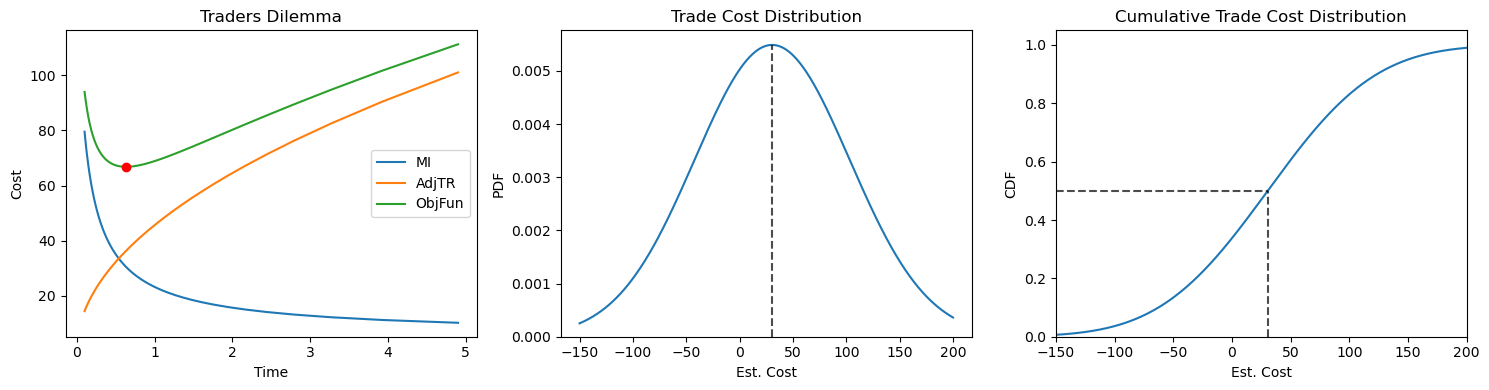

In [2]:
# Q1 Parameters
Side_q1 = 1
Size_q1 = 0.10
Vol_q1 = 0.25
Lambda_q1 = 0.5

# Objective Function
def obj_q1(pov):
    t = PovToTime(Size_q1, pov)
    mi = MI(Size_q1, Vol_q1, pov)
    tr = TR(Vol_q1, t)
    return mi + Lambda_q1 * tr

# Optimization
res_q1 = minimize(obj_q1, x0=[0.15], bounds=[(0.01, 0.99)])
opt_pov_q1 = res_q1.x[0]
opt_time_q1 = PovToTime(Size_q1, opt_pov_q1)
opt_mi_q1 = MI(Size_q1, Vol_q1, opt_pov_q1)
opt_tr_q1 = TR(Vol_q1, opt_time_q1)
exp_cost_q1 = opt_mi_q1 # Expected Cost = MI (PA is 0 since AlphaBp is not given)

print("--Q1 Results ---")
print(f"Optimal POV: {opt_pov_q1*100:.2f}%")
print(f"MI: {opt_mi_q1:.2f}")
print(f"TR: {opt_tr_q1:.2f}")
print(f"Trade Time: {opt_time_q1:.4f}")

# Plotting Trader's Dilemma
pov_range = np.linspace(0.02, 0.50, 100)
times = [PovToTime(Size_q1, p) for p in pov_range]
costs = [obj_q1(p) for p in pov_range]
mis = [MI(Size_q1, Vol_q1, p) for p in pov_range]
adj_trs = [Lambda_q1 * TR(Vol_q1, t) for t in times]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(times, mis, label='MI')
plt.plot(times, adj_trs, label='AdjTR')
plt.plot(times, costs, label='ObjFun')
plt.scatter(opt_time_q1, obj_q1(opt_pov_q1), color='red', zorder=5)
plt.title("Traders Dilemma")
plt.xlabel("Time")
plt.ylabel("Cost")
plt.legend()

# Plotting PDF & CDF
x = np.linspace(-150, 200, 500)
pdf = stats.norm.pdf(x, loc=exp_cost_q1, scale=opt_tr_q1)
cdf = stats.norm.cdf(x, loc=exp_cost_q1, scale=opt_tr_q1)

plt.subplot(1, 3, 2)
plt.plot(x, pdf)
peak_y = stats.norm.pdf(exp_cost_q1, loc=exp_cost_q1, scale=opt_tr_q1)
# FIX: Vertical line stops exactly at the PDF peak
plt.vlines(x=exp_cost_q1, ymin=0, ymax=peak_y, colors='k', linestyles='--', alpha=0.7)
plt.ylim(bottom=0)
plt.title("Trade Cost Distribution")
plt.xlabel("Est. Cost")
plt.ylabel("PDF")

plt.subplot(1, 3, 3)
plt.plot(x, cdf)
# FIX: Bounded horizontal and vertical line segments
plt.hlines(y=0.5, xmin=x.min(), xmax=exp_cost_q1, colors='k', linestyles='--', alpha=0.7)
plt.vlines(x=exp_cost_q1, ymin=0, ymax=0.5, colors='k', linestyles='--', alpha=0.7)
plt.xlim(x.min(), x.max())
plt.ylim(0, 1.05)
plt.title("Cumulative Trade Cost Distribution")
plt.xlabel("Est. Cost")
plt.ylabel("CDF")

plt.tight_layout()
plt.show()

--- Q2 Results ---
Optimal POV: 18.48%
MI: 37.75
PA: 22.06
TR: 60.63
Trade Time: 0.4412


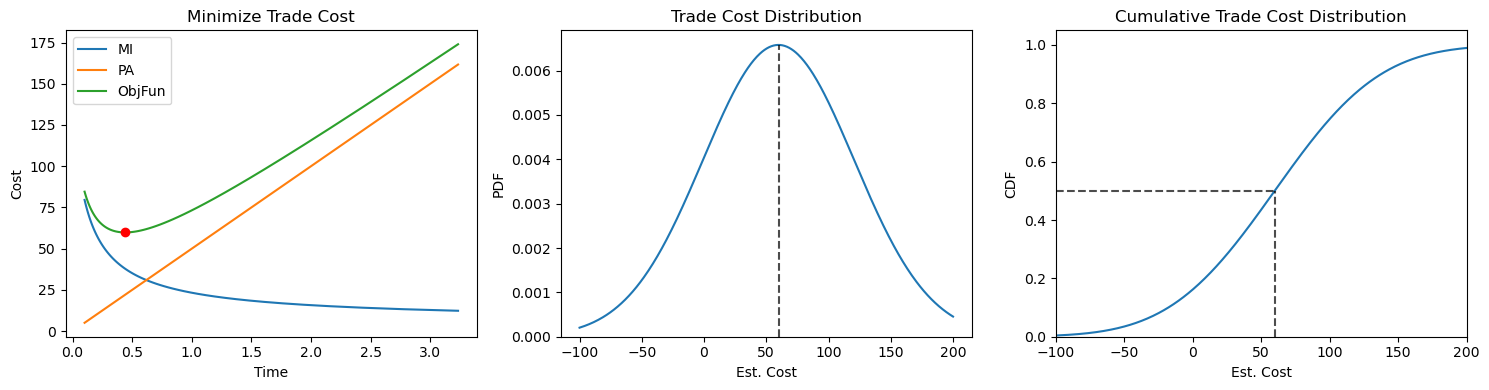

In [10]:
# Q2 Parameters
Side_q2 = 1
Size_q2 = 0.10
Vol_q2 = 0.25
Alpha_q2 = 100

# Objective Function
def obj_q2(pov):
    t = PovToTime(Size_q2, pov)
    mi = MI(Size_q2, Vol_q2, pov)
    pa = PA(Side_q2, Alpha_q2, t)
    return mi + pa

# Optimization
res_q2 = minimize(obj_q2, x0=[0.15], bounds=[(0.01, 0.99)])
opt_pov_q2 = res_q2.x[0]
opt_time_q2 = PovToTime(Size_q2, opt_pov_q2)
opt_mi_q2 = MI(Size_q2, Vol_q2, opt_pov_q2)
opt_pa_q2 = PA(Side_q2, Alpha_q2, opt_time_q2)
opt_tr_q2 = TR(Vol_q2, opt_time_q2)
exp_cost_q2 = opt_mi_q2 + opt_pa_q2 # Mean for distribution

print("--- Q2 Results ---")
print(f"Optimal POV: {opt_pov_q2*100:.2f}%")
print(f"MI: {opt_mi_q2:.2f}")
print(f"PA: {opt_pa_q2:.2f}")
print(f"TR: {opt_tr_q2:.2f}")
print(f"Trade Time: {opt_time_q2:.4f}")

# Plotting Minimize Trade Cost
pov_range = np.linspace(0.03, 0.50, 100)
times2 = [PovToTime(Size_q2, p) for p in pov_range]
costs2 = [obj_q2(p) for p in pov_range]
mis2 = [MI(Size_q2, Vol_q2, p) for p in pov_range]
pas2 = [PA(Side_q2, Alpha_q2, t) for t in times2]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(times2, mis2, label='MI')
plt.plot(times2, pas2, label='PA')
plt.plot(times2, costs2, label='ObjFun')
plt.scatter(opt_time_q2, obj_q2(opt_pov_q2), color='red', zorder=5)
plt.title("Minimize Trade Cost")
plt.xlabel("Time")
plt.ylabel("Cost")
plt.legend()

# Plotting PDF & CDF
x2 = np.linspace(-100, 200, 500)
pdf2 = stats.norm.pdf(x2, loc=exp_cost_q2, scale=opt_tr_q2)
cdf2 = stats.norm.cdf(x2, loc=exp_cost_q2, scale=opt_tr_q2)

plt.subplot(1, 3, 2)
plt.plot(x2, pdf2)
peak_y2 = stats.norm.pdf(exp_cost_q2, loc=exp_cost_q2, scale=opt_tr_q2)
plt.vlines(x=exp_cost_q2, ymin=0, ymax=peak_y2, colors='k', linestyles='--', alpha=0.7)
plt.ylim(bottom=0)
plt.title("Trade Cost Distribution")
plt.xlabel("Est. Cost")
plt.ylabel("PDF")

plt.subplot(1, 3, 3)
plt.plot(x2, cdf2)
plt.hlines(y=0.5, xmin=x2.min(), xmax=exp_cost_q2, colors='k', linestyles='--', alpha=0.7)
plt.vlines(x=exp_cost_q2, ymin=0, ymax=0.5, colors='k', linestyles='--', alpha=0.7)
plt.xlim(x2.min(), x2.max())
plt.ylim(0, 1.05)
plt.title("Cumulative Trade Cost Distribution")
plt.xlabel("Est. Cost")
plt.ylabel("CDF")

plt.tight_layout()
plt.show()

--- Q3 Results ---
Optimal POV: 25.36%
MI: 47.54
TR: 49.53
Trade Time: 0.2944


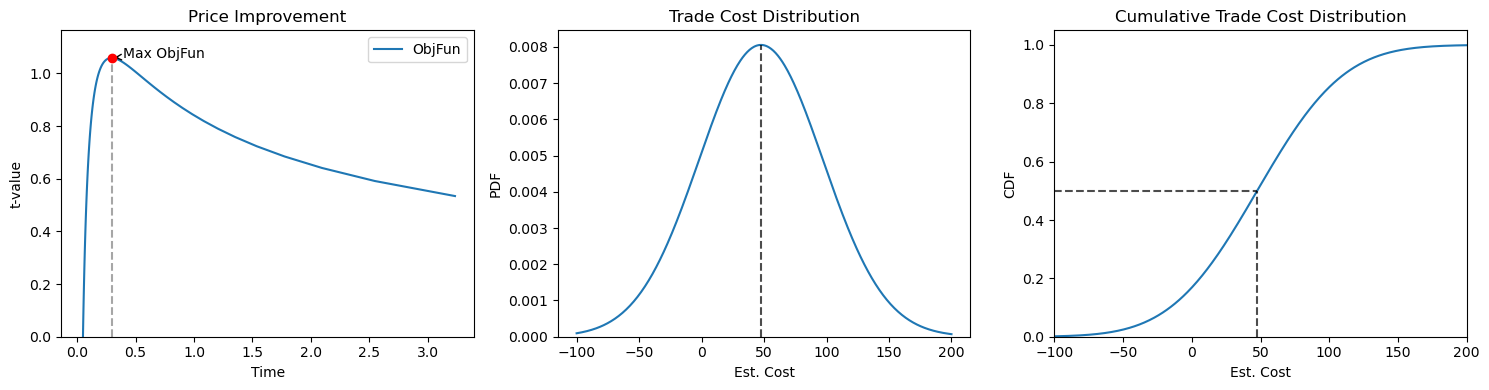

In [11]:
# Q3 Parameters
Side_q3 = 1
Size_q3 = 0.10
Vol_q3 = 0.25
Bid_q3 = 100

# Objective Function
def obj_q3(pov):
    t = PovToTime(Size_q3, pov)
    mi = MI(Size_q3, Vol_q3, pov)
    tr = TR(Vol_q3, t)
    return (mi - Bid_q3) / tr

# Optimization
res_q3 = minimize(obj_q3, x0=[0.25], bounds=[(0.01, 0.99)])
opt_pov_q3 = res_q3.x[0]
opt_time_q3 = PovToTime(Size_q3, opt_pov_q3)
opt_mi_q3 = MI(Size_q3, Vol_q3, opt_pov_q3)
opt_tr_q3 = TR(Vol_q3, opt_time_q3)
opt_tval_q3 = -obj_q3(opt_pov_q3) # Reverting sign for display purposes (Max ObjFun)
exp_cost_q3 = opt_mi_q3 # Expected Cost = MI (PA is 0)

print("--- Q3 Results ---")
print(f"Optimal POV: {opt_pov_q3*100:.2f}%")
print(f"MI: {opt_mi_q3:.2f}")
print(f"TR: {opt_tr_q3:.2f}")
print(f"Trade Time: {opt_time_q3:.4f}")

# Plotting Price Improvement
pov_range = np.linspace(0.03, 0.80, 100)
times3 = [PovToTime(Size_q3, p) for p in pov_range]
tvals = [-(MI(Size_q3, Vol_q3, p) - Bid_q3) / TR(Vol_q3, PovToTime(Size_q3, p)) for p in pov_range]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(times3, tvals, label='ObjFun')
plt.scatter(opt_time_q3, opt_tval_q3, color='red', zorder=5)
plt.annotate('Max ObjFun', xy=(opt_time_q3, opt_tval_q3), xytext=(opt_time_q3+0.1, opt_tval_q3),
             arrowprops=dict(arrowstyle='->'))
plt.vlines(x=opt_time_q3, ymin=0, ymax=opt_tval_q3, colors='gray', linestyles='--', alpha=0.7)
plt.ylim(bottom=0)
plt.title("Price Improvement")
plt.xlabel("Time")
plt.ylabel("t-value")
plt.legend()

# Plotting PDF & CDF
x3 = np.linspace(-100, 200, 500)
pdf3 = stats.norm.pdf(x3, loc=exp_cost_q3, scale=opt_tr_q3)
cdf3 = stats.norm.cdf(x3, loc=exp_cost_q3, scale=opt_tr_q3)

plt.subplot(1, 3, 2)
plt.plot(x3, pdf3)
peak_y3 = stats.norm.pdf(exp_cost_q3, loc=exp_cost_q3, scale=opt_tr_q3)
plt.vlines(x=exp_cost_q3, ymin=0, ymax=peak_y3, colors='k', linestyles='--', alpha=0.7)
plt.ylim(bottom=0)
plt.title("Trade Cost Distribution")
plt.xlabel("Est. Cost")
plt.ylabel("PDF")

plt.subplot(1, 3, 3)
plt.plot(x3, cdf3)
plt.hlines(y=0.5, xmin=x3.min(), xmax=exp_cost_q3, colors='k', linestyles='--', alpha=0.7)
plt.vlines(x=exp_cost_q3, ymin=0, ymax=0.5, colors='k', linestyles='--', alpha=0.7)
plt.xlim(x3.min(), x3.max())
plt.ylim(0, 1.05)
plt.title("Cumulative Trade Cost Distribution")
plt.xlabel("Est. Cost")
plt.ylabel("CDF")

plt.tight_layout()
plt.show()

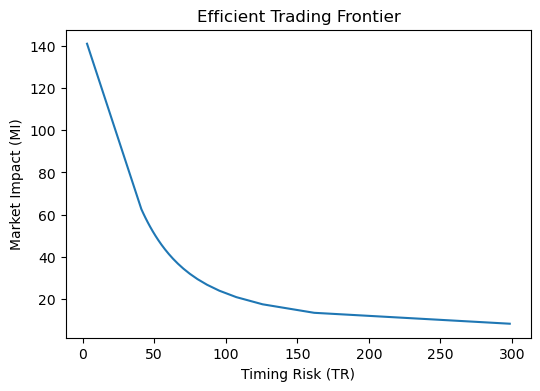

In [12]:
# Q4 Parameters
Shares_q4 = 150000
ADV_q4 = 2000000
Size_q4 = Shares_q4 / ADV_q4
Vol_q4 = 0.30

# Calculate Frontier
frontier_tr = []
frontier_mi = []
lambdas_extended = np.linspace(0.01, 3.5, 50)

for lam in lambdas_extended:
    def obj_q4(pov):
        t = PovToTime(Size_q4, pov)
        return MI(Size_q4, Vol_q4, pov) + lam * TR(Vol_q4, t)
    
    res = minimize(obj_q4, x0=[0.15], bounds=[(0.01, 0.99)])
    opt_p = res.x[0]
    opt_t = PovToTime(Size_q4, opt_p)
    frontier_mi.append(MI(Size_q4, Vol_q4, opt_p))
    frontier_tr.append(TR(Vol_q4, opt_t))

# Plotting Efficient Trading Frontier
plt.figure(figsize=(6, 4))
plt.plot(frontier_tr, frontier_mi)
plt.title("Efficient Trading Frontier")
plt.xlabel("Timing Risk (TR)")
plt.ylabel("Market Impact (MI)")
plt.show()

--- Q5 Results ---
Shares: 449120
MI: 50.0000


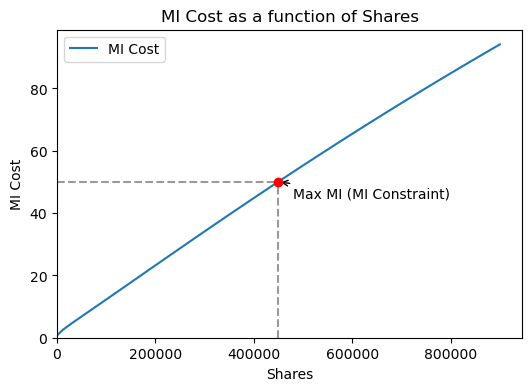

In [15]:
# Q5 Parameters
ADV_q5 = 2000000
Vol_q5 = 0.25
Time_q5 = 1.0
MI_Target = 50.0

# Objective Function to find root
def mi_diff(size):
    pov = TimeToPOV(size, Time_q5)
    return MI(size, Vol_q5, pov) - MI_Target

# Solve for Size
opt_size_q5 = brentq(mi_diff, 0.0001, 1.0)
max_shares_q5 = opt_size_q5 * ADV_q5
opt_pov_q5 = TimeToPOV(opt_size_q5, Time_q5)
actual_mi_q5 = MI(opt_size_q5, Vol_q5, opt_pov_q5)

print("--- Q5 Results ---")
print(f"Shares: {max_shares_q5:.0f}")
print(f"MI: {actual_mi_q5:.4f}")

# Plotting MI Cost as a function of Shares
sizes = np.linspace(0.001, 0.45, 100)
shares = sizes * ADV_q5
mis_q5 = [MI(s, Vol_q5, TimeToPOV(s, Time_q5)) for s in sizes]

plt.figure(figsize=(6, 4))
plt.plot(shares, mis_q5, label='MI Cost')
plt.scatter(max_shares_q5, actual_mi_q5, color='red', zorder=5)

# Bounded lines mapping the point to the axes
plt.hlines(y=actual_mi_q5, xmin=0, xmax=max_shares_q5, colors='gray', linestyles='--', alpha=0.8)
plt.vlines(x=max_shares_q5, ymin=0, ymax=actual_mi_q5, colors='gray', linestyles='--', alpha=0.8)

plt.annotate('Max MI (MI Constraint)', xy=(max_shares_q5, actual_mi_q5), xytext=(max_shares_q5+30000, actual_mi_q5-5),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.title("MI Cost as a function of Shares")
plt.xlabel("Shares")
plt.ylabel("MI Cost")
plt.legend()
plt.show()